In [ ]:
##Test Script

In [27]:
import os
import pickle
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tqdm import tqdm

# =====================================================
# 1️⃣ CONFIGURATION
# =====================================================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🚀 Using device: {DEVICE}")

TEST_FILE = "windows_new/test_windows.pkl"
MODEL_PATH = "model_new.pt"
SCALER_DIR = "scalers_new"
BATCH_SIZE = 64
NORMALIZED_RESULTS_PATH = "./results/test_predictions_normalized.csv"
DENORMALIZED_RESULTS_PATH = "./results/test_predictions_denormalized.csv"

NUMERIC_COLS = [
    "Adj Close", "Close", "High", "Low", "Open",
    "Volume", "Daily_Return", "EMA_7", "EMA_21"
]
CLOSE_IDX = NUMERIC_COLS.index("Close")

# =====================================================
# 2️⃣ LOAD TEST DATA
# =====================================================
with open(TEST_FILE, "rb") as f:
    test_data = pickle.load(f)
print(f"✅ Loaded {len(test_data)} test samples.")

# =====================================================
# 3️⃣ LOAD MODEL CHECKPOINT
# =====================================================
checkpoint = torch.load(MODEL_PATH, map_location=DEVICE,weights_only=False)
companies = checkpoint["companies"]
enc = checkpoint["label_encoder"]
num_companies = len(enc.classes_)

# =====================================================
# 4️⃣ PREPARE TEST DATA WITH ONE-HOT COMPANY FEATURE
# =====================================================
def encode_company(enc, company_name):
    try:
        return enc.transform([company_name])[0]
    except ValueError:
        return None

test_data_encoded = []
for X, next_s, y, c in test_data:
    c_encoded = encode_company(enc, c)
    company_feat = np.zeros(num_companies, dtype=np.float32)
    if c_encoded is not None:
        company_feat[c_encoded] = 1.0
    test_data_encoded.append((X, next_s, y, company_feat))

class WindowDataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        X, next_sent, y, c = self.data[idx]
        X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
        next_sent = np.nan_to_num(next_sent, nan=0.0, posinf=0.0, neginf=0.0)
        y = 0.0 if not np.isfinite(y) else y
        return (
            torch.tensor(X, dtype=torch.float32),
            torch.tensor(next_sent, dtype=torch.float32),
            torch.tensor(y, dtype=torch.float32),
            torch.tensor(c, dtype=torch.float32)
        )

test_loader = DataLoader(WindowDataset(test_data_encoded), batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# =====================================================
# 5️⃣ DEFINE MODEL
# =====================================================
class StockTransformer(nn.Module):
    def __init__(self, feature_dim, sentiment_dim, company_feature_dim):
        super().__init__()
        d_model = 128
        self.input_proj = nn.Linear(feature_dim + company_feature_dim, d_model)
        self.norm = nn.LayerNorm(d_model)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=4,
            batch_first=True,
            activation='gelu'
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=2)

        self.sentiment_proj = nn.Linear(sentiment_dim, 32)
        self.fc = nn.Sequential(
            nn.Linear(d_model + 32, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x, next_sent, company_feat):
        company_feat_exp = company_feat.unsqueeze(1).expand(-1, x.size(1), -1)
        x = torch.cat([x, company_feat_exp], dim=-1)
        x = self.input_proj(x)
        x = self.norm(x)
        x = self.encoder(x)
        seq_out = x[:, -1, :]
        sent_embed = self.sentiment_proj(next_sent)
        combined = torch.cat([seq_out, sent_embed], dim=-1)
        return self.fc(combined).squeeze(-1)

# =====================================================
# 6️⃣ INITIALIZE MODEL
# =====================================================
feature_dim = test_data_encoded[0][0].shape[1]
sentiment_dim = test_data_encoded[0][1].shape[0]

model = StockTransformer(feature_dim, sentiment_dim, num_companies).to(DEVICE)
model.load_state_dict(checkpoint["model_state"])
model.eval()
print("✅ Model loaded and ready for testing.")

# =====================================================
# 7️⃣ LOAD SCALERS
# =====================================================
scalers = {}
for company in companies:
    scaler_path = os.path.join(SCALER_DIR, f"{company}_scaler.pkl")
    if os.path.exists(scaler_path):
        with open(scaler_path, "rb") as f:
            scalers[company] = pickle.load(f)
    else:
        print(f"⚠️ No scaler found for {company}, using identity.")

# =====================================================
# 8️⃣ TEST LOOP
# =====================================================
all_targets_norm, all_preds_norm, all_companies = [], [], []
all_targets_denorm, all_preds_denorm = [], []

with torch.no_grad():
    for (X_batch, next_sent_batch, y_batch, c_batch), batch_data in zip(
            test_loader, [test_data[i:i+BATCH_SIZE] for i in range(0, len(test_data), BATCH_SIZE)]):

        X_batch, next_sent_batch, y_batch, c_batch = X_batch.to(DEVICE), next_sent_batch.to(DEVICE), y_batch.to(DEVICE), c_batch.to(DEVICE)
        preds_batch = model(X_batch, next_sent_batch, c_batch).cpu().numpy()
        y_batch_np = y_batch.cpu().numpy()

        for i, (_, _, y_val, company_name) in enumerate(batch_data):
            # Normalized values
            all_targets_norm.append(y_val)
            all_preds_norm.append(preds_batch[i])
            all_companies.append(company_name)

            # Denormalize using min-max formula on Close column
            scaler = scalers.get(company_name, None)
            if scaler is not None:
                min_close = scaler.data_min_[CLOSE_IDX]
                max_close = scaler.data_max_[CLOSE_IDX]

                y_denorm_val = y_val * (max_close - min_close) + min_close
                y_pred_denorm_val = preds_batch[i] * (max_close - min_close) + min_close
            else:
                y_denorm_val = y_val
                y_pred_denorm_val = preds_batch[i]

            # Append to denormalized lists **inside the loop**
            all_targets_denorm.append(y_denorm_val)
            all_preds_denorm.append(y_pred_denorm_val)

# =====================================================
# 9️⃣ SAVE RESULTS
# =====================================================
os.makedirs(os.path.dirname(NORMALIZED_RESULTS_PATH), exist_ok=True)
df_norm = pd.DataFrame({
    "Company": all_companies,
    "Target": all_targets_norm,
    "Predicted": all_preds_norm
})
df_norm.to_csv(NORMALIZED_RESULTS_PATH, index=False)

df_denorm = pd.DataFrame({
    "Company": all_companies,
    "Target": all_targets_denorm,
    "Predicted": all_preds_denorm
})
df_denorm.to_csv(DENORMALIZED_RESULTS_PATH, index=False)

print(f"✅ Normalized predictions saved to '{NORMALIZED_RESULTS_PATH}'")
print(f"✅ Denormalized predictions saved to '{DENORMALIZED_RESULTS_PATH}'")

# =====================================================
# 🔟 EVALUATION METRICS (DENORMALIZED)
# =====================================================
mse = mean_squared_error(all_targets_denorm, all_preds_denorm)
mae = mean_absolute_error(all_targets_denorm, all_preds_denorm)
r2 = r2_score(all_targets_denorm, all_preds_denorm)
print("\n📊 Denormalized Test Results:")
print(f"MSE: {mse:.6f}, MAE: {mae:.6f}, R2: {r2:.6f}")

🚀 Using device: cuda
✅ Loaded 1990 test samples.
✅ Model loaded and ready for testing.
✅ Normalized predictions saved to './results/test_predictions_normalized.csv'
✅ Denormalized predictions saved to './results/test_predictions_denormalized.csv'

📊 Denormalized Test Results:
MSE: 0.009353, MAE: 0.080501, R2: 0.842414


In [ ]:
import os
import pickle
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tqdm import tqdm

# =====================================================
# 1️⃣ CONFIGURATION
# =====================================================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🚀 Using device: {DEVICE}")

TEST_FILE = "windows_last/test_windows.pkl"
MODEL_PATH = "model_final.pt"
SCALER_DIR = "scalers_last"
BATCH_SIZE = 64
NORMALIZED_RESULTS_PATH = "./results/test_predictions_normalized.csv"
DENORMALIZED_RESULTS_PATH = "./results/test_predictions_denormalized.csv"

NUMERIC_COLS = [
    "Adj Close", "Close", "High", "Low", "Open",
    "Volume", "Daily_Return", "EMA_7", "EMA_21"
]
CLOSE_IDX = NUMERIC_COLS.index("Close")

# =====================================================
# 2️⃣ LOAD TEST DATA
# =====================================================
with open(TEST_FILE, "rb") as f:
    test_data = pickle.load(f)
print(f"✅ Loaded {len(test_data)} test samples.")

# =====================================================
# 3️⃣ LOAD MODEL CHECKPOINT
# =====================================================
checkpoint = torch.load(MODEL_PATH, map_location=DEVICE,weights_only=False)
companies = checkpoint["companies"]
enc = checkpoint["label_encoder"]
num_companies = len(enc.classes_)

# =====================================================
# 4️⃣ PREPARE TEST DATA WITH ONE-HOT COMPANY FEATURE
# =====================================================
def encode_company(enc, company_name):
    try:
        return enc.transform([company_name])[0]
    except ValueError:
        return None

test_data_encoded = []
for X, next_s, y, c in test_data:
    c_encoded = encode_company(enc, c)
    company_feat = np.zeros(num_companies, dtype=np.float32)
    if c_encoded is not None:
        company_feat[c_encoded] = 1.0
    test_data_encoded.append((X, next_s, y, company_feat))

class WindowDataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        X, next_sent, y, c = self.data[idx]
        X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
        next_sent = np.nan_to_num(next_sent, nan=0.0, posinf=0.0, neginf=0.0)
        y = 0.0 if not np.isfinite(y) else y
        return (
            torch.tensor(X, dtype=torch.float32),
            torch.tensor(next_sent, dtype=torch.float32),
            torch.tensor(y, dtype=torch.float32),
            torch.tensor(c, dtype=torch.float32)
        )

test_loader = DataLoader(WindowDataset(test_data_encoded), batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# =====================================================
# 5️⃣ DEFINE MODEL
# =====================================================
class StockTransformer(nn.Module):
    def __init__(self, feature_dim, sentiment_dim, company_feature_dim):
        super().__init__()
        d_model = 128
        self.input_proj = nn.Linear(feature_dim + company_feature_dim, d_model)
        self.norm = nn.LayerNorm(d_model)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=4,
            batch_first=True,
            activation='gelu'
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=2)

        self.sentiment_proj = nn.Linear(sentiment_dim, 32)
        self.fc = nn.Sequential(
            nn.Linear(d_model + 32, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x, next_sent, company_feat):
        company_feat_exp = company_feat.unsqueeze(1).expand(-1, x.size(1), -1)
        x = torch.cat([x, company_feat_exp], dim=-1)
        x = self.input_proj(x)
        x = self.norm(x)
        x = self.encoder(x)
        seq_out = x[:, -1, :]
        sent_embed = self.sentiment_proj(next_sent)
        combined = torch.cat([seq_out, sent_embed], dim=-1)
        return self.fc(combined).squeeze(-1)

# =====================================================
# 6️⃣ INITIALIZE MODEL
# =====================================================
feature_dim = test_data_encoded[0][0].shape[1]
sentiment_dim = test_data_encoded[0][1].shape[0]

model = StockTransformer(feature_dim, sentiment_dim, num_companies).to(DEVICE)
model.load_state_dict(checkpoint["model_state"])
model.eval()
print("✅ Model loaded and ready for testing.")

# =====================================================
# 7️⃣ LOAD SCALERS
# =====================================================
scalers = {}
for company in companies:
    scaler_path = os.path.join(SCALER_DIR, f"{company}_scaler.pkl")
    if os.path.exists(scaler_path):
        with open(scaler_path, "rb") as f:
            scalers[company] = pickle.load(f)
    else:
        print(f"⚠️ No scaler found for {company}, using identity.")

# =====================================================
# 8️⃣ TEST LOOP
# =====================================================
all_targets_norm, all_preds_norm, all_companies = [], [], []
all_targets_denorm, all_preds_denorm = [], []

with torch.no_grad():
    for (X_batch, next_sent_batch, y_batch, c_batch), batch_data in zip(
            test_loader, [test_data[i:i+BATCH_SIZE] for i in range(0, len(test_data), BATCH_SIZE)]):

        X_batch, next_sent_batch, y_batch, c_batch = X_batch.to(DEVICE), next_sent_batch.to(DEVICE), y_batch.to(DEVICE), c_batch.to(DEVICE)
        preds_batch = model(X_batch, next_sent_batch, c_batch).cpu().numpy()
        y_batch_np = y_batch.cpu().numpy()

        for i, (_, _, y_val, company_name) in enumerate(batch_data):
            # Normalized values
            all_targets_norm.append(y_val)
            all_preds_norm.append(preds_batch[i])
            all_companies.append(company_name)

            # Denormalize using min-max formula on Close column
            scaler = scalers.get(company_name, None)

            y_denorm_val = y_val
            y_pred_denorm_val = preds_batch[i]

            # Append to denormalized lists **inside the loop**
            all_targets_denorm.append(y_denorm_val)
            all_preds_denorm.append(y_pred_denorm_val)

# =====================================================
# 9️⃣ SAVE RESULTS
# =====================================================
os.makedirs(os.path.dirname(NORMALIZED_RESULTS_PATH), exist_ok=True)
df_norm = pd.DataFrame({
    "Company": all_companies,
    "Target": all_targets_norm,
    "Predicted": all_preds_norm
})
df_norm.to_csv(NORMALIZED_RESULTS_PATH, index=False)

df_denorm = pd.DataFrame({
    "Company": all_companies,
    "Target": all_targets_denorm,
    "Predicted": all_preds_denorm
})
df_denorm.to_csv(DENORMALIZED_RESULTS_PATH, index=False)

print(f"✅ Normalized predictions saved to '{NORMALIZED_RESULTS_PATH}'")
print(f"✅ Denormalized predictions saved to '{DENORMALIZED_RESULTS_PATH}'")

# =====================================================
# 🔟 EVALUATION METRICS
# =====================================================
mae = mean_absolute_error(all_targets_denorm, all_preds_denorm)
r2 = r2_score(all_targets_denorm, all_preds_denorm)

# MAPE: Mean Absolute Percentage Error
all_targets_denorm_np = np.array(all_targets_denorm)
all_preds_denorm_np = np.array(all_preds_denorm)
# Avoid division by zero
mask = all_targets_denorm_np != 0
mape = np.mean(np.abs((all_targets_denorm_np[mask] - all_preds_denorm_np[mask]) / all_targets_denorm_np[mask])) * 100

print("\n📊 Denormalized Test Results:")
print(f"MAPE: {mape:.2f}%, MAE: {mae:.6f}, R2: {r2:.6f}")

🚀 Using device: cuda
✅ Loaded 1990 test samples.
✅ Model loaded and ready for testing.
✅ Normalized predictions saved to './results/test_predictions_normalized.csv'
✅ Denormalized predictions saved to './results/test_predictions_denormalized.csv'

📊 Denormalized Test Results:
MAPE: 46.99%, MAE: 122.812714, R2: -1.372238, Directional Accuracy: 75.01%


In [67]:
import os
import pickle
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_absolute_error, r2_score
from tqdm import tqdm

# =====================================================
# 1️⃣ CONFIGURATION
# =====================================================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🚀 Using device: {DEVICE}")

TEST_FILE = "windows_new/test_windows.pkl"
MODEL_PATH = "model.pt"
SCALER_DIR = "scalers_new"
BATCH_SIZE = 64
NORMALIZED_RESULTS_PATH = "./results/predictions_normalized.csv"
DENORMALIZED_RESULTS_PATH = "./results/predictions_denormalized.csv"

NUMERIC_COLS = [
    "Adj Close", "Close", "High", "Low", "Open",
    "Volume", "Daily_Return", "EMA_7", "EMA_21"
]
CLOSE_IDX = NUMERIC_COLS.index("Close")

# =====================================================
# 2️⃣ LOAD TEST DATA
# =====================================================
with open(TEST_FILE, "rb") as f:
    test_data = pickle.load(f)
print(f"✅ Loaded {len(test_data)} test samples.")

# =====================================================
# 3️⃣ LOAD MODEL CHECKPOINT
# =====================================================
checkpoint = torch.load(MODEL_PATH, map_location=DEVICE, weights_only=False)
companies = checkpoint["companies"]
enc = checkpoint["label_encoder"]
num_companies = len(enc.classes_)

# =====================================================
# 4️⃣ PREPARE TEST DATA
# =====================================================
def encode_company(enc, company_name):
    try:
        return enc.transform([company_name])[0]
    except ValueError:
        return None

test_data_encoded = []
for X, next_s, y, c in test_data:
    c_encoded = encode_company(enc, c)
    company_feat = np.zeros(num_companies, dtype=np.float32)
    if c_encoded is not None:
        company_feat[c_encoded] = 1.0
    test_data_encoded.append((X, next_s, y, company_feat, c))  # save company name

class WindowDataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        X, next_sent, y, c_feat, company_name = self.data[idx]
        X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
        next_sent = np.nan_to_num(next_sent, nan=0.0, posinf=0.0, neginf=0.0)
        y = 0.0 if not np.isfinite(y) else y
        return (
            torch.tensor(X, dtype=torch.float32),
            torch.tensor(next_sent, dtype=torch.float32),
            torch.tensor(y, dtype=torch.float32),
            torch.tensor(c_feat, dtype=torch.float32),
            company_name
        )

test_loader = DataLoader(WindowDataset(test_data_encoded), batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# =====================================================
# 5️⃣ DEFINE MODEL
# =====================================================
class StockTransformer(nn.Module):
    def __init__(self, feature_dim, sentiment_dim, company_feature_dim):
        super().__init__()
        d_model = 128
        self.input_proj = nn.Linear(feature_dim + company_feature_dim, d_model)
        self.norm = nn.LayerNorm(d_model)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=4,
            batch_first=True,
            activation='gelu'
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=2)

        self.sentiment_proj = nn.Linear(sentiment_dim, 32)
        self.fc = nn.Sequential(
            nn.Linear(d_model + 32, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x, next_sent, company_feat):
        company_feat_exp = company_feat.unsqueeze(1).expand(-1, x.size(1), -1)
        x = torch.cat([x, company_feat_exp], dim=-1)
        x = self.input_proj(x)
        x = self.norm(x)
        x = self.encoder(x)
        seq_out = x[:, -1, :]
        sent_embed = self.sentiment_proj(next_sent)
        combined = torch.cat([seq_out, sent_embed], dim=-1)
        return self.fc(combined).squeeze(-1)

# =====================================================
# 6️⃣ INITIALIZE MODEL
# =====================================================
feature_dim = test_data_encoded[0][0].shape[1]
sentiment_dim = test_data_encoded[0][1].shape[0]

model = StockTransformer(feature_dim, sentiment_dim, num_companies).to(DEVICE)
model.load_state_dict(checkpoint["model_state"])
model.eval()
print("✅ Model loaded and ready for testing.")

# =====================================================
# 7️⃣ LOAD SCALERS
# =====================================================
scalers = {}
for company in companies:
    scaler_path = os.path.join(SCALER_DIR, f"{company}_scaler.pkl")
    if os.path.exists(scaler_path):
        with open(scaler_path, "rb") as f:
            scalers[company] = pickle.load(f)
    else:
        print(f"⚠️ No scaler found for {company}, using identity.")

# =====================================================
# 8️⃣ TEST LOOP WITH DENORMALIZATION
# =====================================================
all_targets_norm, all_preds_norm, all_companies = [], [], []
all_targets_denorm, all_preds_denorm = [], []

with torch.no_grad():
    for X_batch, next_sent_batch, y_batch, c_batch, company_batch in test_loader:
        X_batch, next_sent_batch, y_batch, c_batch = X_batch.to(DEVICE), next_sent_batch.to(DEVICE), y_batch.to(DEVICE), c_batch.to(DEVICE)
        preds_batch = model(X_batch, next_sent_batch, c_batch).cpu().numpy()
        y_batch_np = y_batch.cpu().numpy()

        for i, company_name in enumerate(company_batch):
            y_val = y_batch_np[i]
            y_pred = preds_batch[i]

            # Normalized
            all_targets_norm.append(y_val)
            all_preds_norm.append(y_pred)
            all_companies.append(company_name)

            # Denormalize Close price
            scaler = scalers.get(company_name, None)
            if scaler:
                y_denorm = scaler.data_min_[CLOSE_IDX] + y_val * (scaler.data_max_[CLOSE_IDX] - scaler.data_min_[CLOSE_IDX])
                y_pred_denorm = scaler.data_min_[CLOSE_IDX] + y_pred * (scaler.data_max_[CLOSE_IDX] - scaler.data_min_[CLOSE_IDX])
            else:
                y_denorm = y_val
                y_pred_denorm = y_pred

            all_targets_denorm.append(y_denorm)
            all_preds_denorm.append(y_pred_denorm)

# =====================================================
# 9️⃣ SAVE RESULTS
# =====================================================
os.makedirs(os.path.dirname(NORMALIZED_RESULTS_PATH), exist_ok=True)
pd.DataFrame({
    "Company": all_companies,
    "Target": all_targets_norm,
    "Predicted": all_preds_norm
}).to_csv(NORMALIZED_RESULTS_PATH, index=False)

pd.DataFrame({
    "Company": all_companies,
    "Target": all_targets_denorm,
    "Predicted": all_preds_denorm
}).to_csv(DENORMALIZED_RESULTS_PATH, index=False)

# =====================================================
# 🔟 EVALUATION METRICS
# =====================================================
all_targets_denorm_np = np.array(all_targets_denorm)
all_preds_denorm_np = np.array(all_preds_denorm)

mae = mean_absolute_error(all_targets_denorm_np, all_preds_denorm_np)
r2 = r2_score(all_targets_denorm_np, all_preds_denorm_np)
mask = all_targets_denorm_np != 0
mape = np.mean(np.abs((all_targets_denorm_np[mask] - all_preds_denorm_np[mask]) / all_targets_denorm_np[mask])) * 100

actual_diff = np.diff(all_targets_denorm_np)
pred_diff = np.diff(all_preds_denorm_np)
mask_dir = actual_diff != 0
directional_accuracy = np.sum((actual_diff[mask_dir] * pred_diff[mask_dir]) > 0) / np.sum(mask_dir) * 100

print("\n📊 Denormalized Test Results:")
print(f"MAPE: {mape:.2f}%, MAE: {mae:.6f}, R2: {r2:.6f}, Directional Accuracy: {directional_accuracy:.2f}%")

🚀 Using device: cuda
✅ Loaded 1990 test samples.
✅ Model loaded and ready for testing.

📊 Denormalized Test Results:
MAPE: 39.26%, MAE: 0.090758, R2: 0.825107, Directional Accuracy: 93.26%


In [69]:
import os
import pickle
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_absolute_error, r2_score
from tqdm import tqdm

# =====================================================
# 1️⃣ CONFIGURATION
# =====================================================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🚀 Using device: {DEVICE}")

TEST_FILE = "windows_new/test_windows.pkl"
MODEL_PATH = "model.pt"
SCALER_DIR = "scalers_new"
BATCH_SIZE = 64
NORMALIZED_RESULTS_PATH = "./results/predictions_normalized.csv"
DENORMALIZED_RESULTS_PATH = "./results/predictions_denormalized.csv"

NUMERIC_COLS = [
    "Adj Close", "Close", "High", "Low", "Open",
    "Volume", "Daily_Return", "EMA_7", "EMA_21"
]
CLOSE_IDX = NUMERIC_COLS.index("Close")

# =====================================================
# 2️⃣ LOAD TEST DATA
# =====================================================
with open(TEST_FILE, "rb") as f:
    test_data = pickle.load(f)
print(f"✅ Loaded {len(test_data)} test samples.")

# =====================================================
# 3️⃣ LOAD MODEL CHECKPOINT
# =====================================================
checkpoint = torch.load(MODEL_PATH, map_location=DEVICE, weights_only=False)
companies = checkpoint["companies"]
enc = checkpoint["label_encoder"]
num_companies = len(enc.classes_)

# =====================================================
# 4️⃣ PREPARE TEST DATA
# =====================================================
def encode_company(enc, company_name):
    try:
        return enc.transform([company_name])[0]
    except ValueError:
        return None

test_data_encoded = []
for X, next_s, y, c in test_data:
    c_encoded = encode_company(enc, c)
    company_feat = np.zeros(num_companies, dtype=np.float32)
    if c_encoded is not None:
        company_feat[c_encoded] = 1.0
    test_data_encoded.append((X, next_s, y, company_feat, c))  # save company name

class WindowDataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        X, next_sent, y, c_feat, company_name = self.data[idx]
        X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
        next_sent = np.nan_to_num(next_sent, nan=0.0, posinf=0.0, neginf=0.0)
        y = 0.0 if not np.isfinite(y) else y
        return (
            torch.tensor(X, dtype=torch.float32),
            torch.tensor(next_sent, dtype=torch.float32),
            torch.tensor(y, dtype=torch.float32),
            torch.tensor(c_feat, dtype=torch.float32),
            company_name
        )

test_loader = DataLoader(WindowDataset(test_data_encoded), batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# =====================================================
# 5️⃣ DEFINE MODEL
# =====================================================
class StockTransformer(nn.Module):
    def __init__(self, feature_dim, sentiment_dim, company_feature_dim):
        super().__init__()
        d_model = 128
        self.input_proj = nn.Linear(feature_dim + company_feature_dim, d_model)
        self.norm = nn.LayerNorm(d_model)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=4,
            batch_first=True,
            activation='gelu'
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=2)

        self.sentiment_proj = nn.Linear(sentiment_dim, 32)
        self.fc = nn.Sequential(
            nn.Linear(d_model + 32, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x, next_sent, company_feat):
        company_feat_exp = company_feat.unsqueeze(1).expand(-1, x.size(1), -1)
        x = torch.cat([x, company_feat_exp], dim=-1)
        x = self.input_proj(x)
        x = self.norm(x)
        x = self.encoder(x)
        seq_out = x[:, -1, :]
        sent_embed = self.sentiment_proj(next_sent)
        combined = torch.cat([seq_out, sent_embed], dim=-1)
        return self.fc(combined).squeeze(-1)

# =====================================================
# 6️⃣ INITIALIZE MODEL
# =====================================================
feature_dim = test_data_encoded[0][0].shape[1]
sentiment_dim = test_data_encoded[0][1].shape[0]

model = StockTransformer(feature_dim, sentiment_dim, num_companies).to(DEVICE)
model.load_state_dict(checkpoint["model_state"])
model.eval()
print("✅ Model loaded and ready for testing.")

# =====================================================
# 7️⃣ LOAD SCALERS (_y_scaler.pkl)
# =====================================================
scalers = {}
for scaler_file in os.listdir(SCALER_DIR):
    if scaler_file.endswith("_y_scaler.pkl"):
        company_name = scaler_file.replace("_y_scaler.pkl", "")
        with open(os.path.join(SCALER_DIR, scaler_file), "rb") as f:
            scalers[company_name] = pickle.load(f)

# =====================================================
# 8️⃣ TEST LOOP WITH DENORMALIZATION
# =====================================================
all_targets_norm, all_preds_norm, all_companies = [], [], []
all_targets_denorm, all_preds_denorm = [], []

with torch.no_grad():
    for X_batch, next_sent_batch, y_batch, c_batch, company_batch in tqdm(test_loader):
        X_batch, next_sent_batch, y_batch, c_batch = X_batch.to(DEVICE), next_sent_batch.to(DEVICE), y_batch.to(DEVICE), c_batch.to(DEVICE)
        preds_batch = model(X_batch, next_sent_batch, c_batch).cpu().numpy()
        y_batch_np = y_batch.cpu().numpy()

        for i, company_name in enumerate(company_batch):
            y_val = y_batch_np[i]
            y_pred = preds_batch[i]

            # Normalized
            all_targets_norm.append(y_val)
            all_preds_norm.append(y_pred)
            all_companies.append(company_name)

            # Denormalize Close price using company-specific y_scaler
            scaler = scalers.get(company_name, None)
            if scaler:
                y_denorm = scaler.inverse_transform([[y_val]])[0][0]
                y_pred_denorm = scaler.inverse_transform([[y_pred]])[0][0]
            else:
                y_denorm = y_val
                y_pred_denorm = y_pred

            all_targets_denorm.append(y_denorm)
            all_preds_denorm.append(y_pred_denorm)

# =====================================================
# 9️⃣ SAVE RESULTS
# =====================================================
os.makedirs(os.path.dirname(NORMALIZED_RESULTS_PATH), exist_ok=True)
pd.DataFrame({
    "Company": all_companies,
    "Target": all_targets_norm,
    "Predicted": all_preds_norm
}).to_csv(NORMALIZED_RESULTS_PATH, index=False)

pd.DataFrame({
    "Company": all_companies,
    "Target": all_targets_denorm,
    "Predicted": all_preds_denorm
}).to_csv(DENORMALIZED_RESULTS_PATH, index=False)
print(f"✅ Saved normalized results to {NORMALIZED_RESULTS_PATH}")
print(f"✅ Saved denormalized results to {DENORMALIZED_RESULTS_PATH}")

# =====================================================
# 🔟 EVALUATION METRICS
# =====================================================
all_targets_denorm_np = np.array(all_targets_denorm)
all_preds_denorm_np = np.array(all_preds_denorm)

mae = mean_absolute_error(all_targets_denorm_np, all_preds_denorm_np)
r2 = r2_score(all_targets_denorm_np, all_preds_denorm_np)
mask = all_targets_denorm_np != 0
mape = np.mean(np.abs((all_targets_denorm_np[mask] - all_preds_denorm_np[mask]) / all_targets_denorm_np[mask])) * 100

actual_diff = np.diff(all_targets_denorm_np)
pred_diff = np.diff(all_preds_denorm_np)
mask_dir = actual_diff != 0
directional_accuracy = np.sum((actual_diff[mask_dir] * pred_diff[mask_dir]) > 0) / np.sum(mask_dir) * 100

print("\n📊 Denormalized Test Results:")
print(f"MAPE: {mape:.2f}%, MAE: {mae:.6f}, R2: {r2:.6f}, Directional Accuracy: {directional_accuracy:.2f}%")


🚀 Using device: cuda
✅ Loaded 1990 test samples.
✅ Model loaded and ready for testing.


100%|██████████| 32/32 [00:00<00:00, 36.59it/s]


✅ Saved normalized results to ./results/predictions_normalized.csv
✅ Saved denormalized results to ./results/predictions_denormalized.csv

📊 Denormalized Test Results:
MAPE: 7.58%, MAE: 18.091279, R2: 0.950613, Directional Accuracy: 96.18%


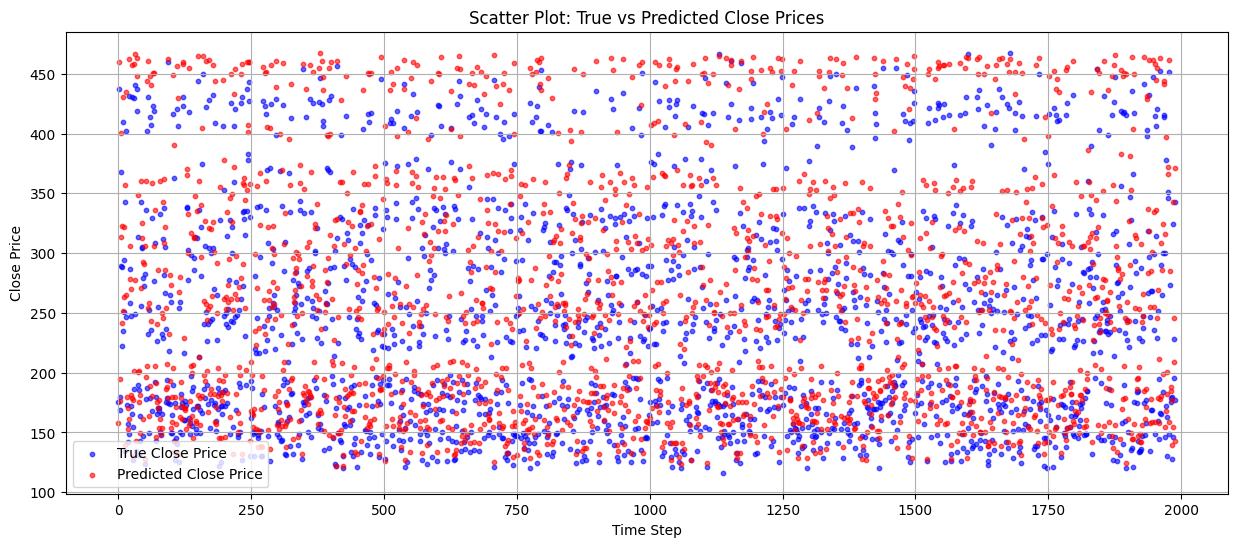

In [72]:
import matplotlib.pyplot as plt

# =====================================================
# SCATTER PLOT: TRUE AND PREDICTED CLOSE PRICES
# =====================================================
plt.figure(figsize=(15, 6))

# True values
plt.scatter(range(len(all_targets_denorm_np)), all_targets_denorm_np,
            color='blue', s=10, alpha=0.6, label='True Close Price')

# Predicted values
plt.scatter(range(len(all_preds_denorm_np)), all_preds_denorm_np,
            color='red', s=10, alpha=0.6, label='Predicted Close Price')

plt.xlabel("Time Step")
plt.ylabel("Close Price")
plt.title("Scatter Plot: True vs Predicted Close Prices")
plt.legend()
plt.grid(True)
plt.show()


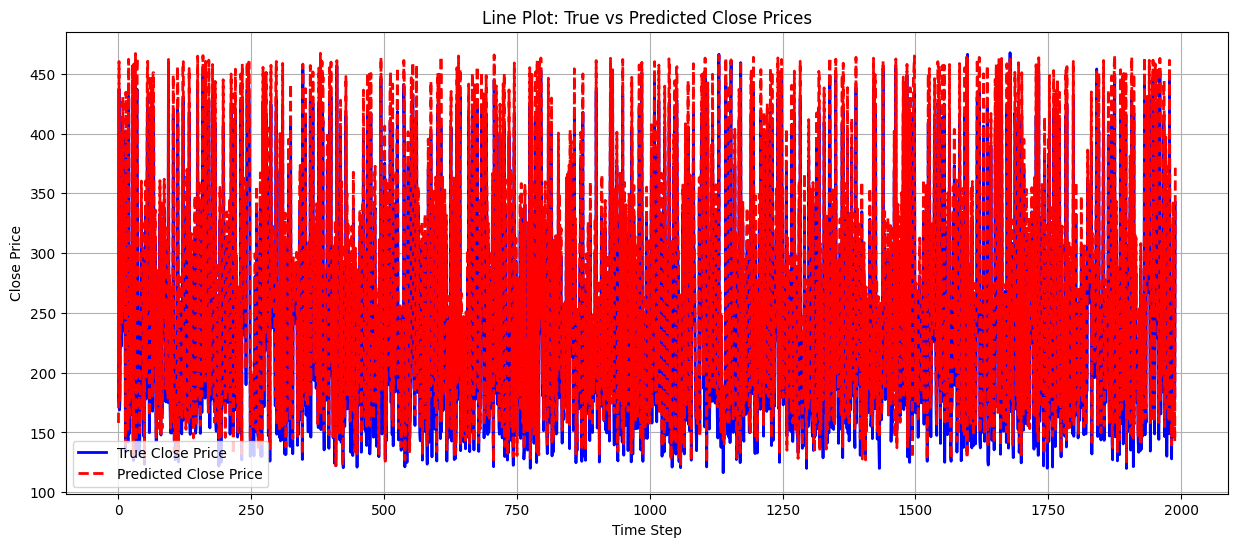

In [ ]:
plt.figure(figsize=(15, 6))

# Plot true and predicted close prices
plt.plot(all_targets_denorm_np, color='blue', linewidth=2, label='True Close Price')
plt.plot(all_preds_denorm_np, color='red', linewidth=2, linestyle='--', label='Predicted Close Price')

plt.xlabel("Time Step")
plt.ylabel("Close Price")
plt.title("Line Plot: True vs Predicted Close Prices")
plt.legend()
plt.grid(True)
plt.show()